In [ ]:
# ============================================
# COMPLETE FIX FOR NUMPY CONFLICT
# ============================================

# Step 1: Uninstall conflicting packages
!pip uninstall -y numpy opencv-python opencv-python-headless mediapipe -q

# Step 2: Install compatible versions in correct order
!pip install numpy==1.26.4 -q
!pip install opencv-python-headless==4.9.0.80 -q
!pip install mediapipe -q --no-deps
!pip install absl-py attrs flatbuffers matplotlib protobuf sounddevice -q
!pip install seaborn -q

print('\n✓ Installation complete!')
print('⚠️ NOW CLICK: Runtime > Restart session')
print('⚠️ Then run the NEXT cell (do NOT run this cell again)')

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_install.py", line 721, in uninstall
    uninstalled_pathset = UninstallPathSet.from_dist(dist)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_uninstall.py", line 517, in from_dist
    for path in uninstallation_paths(dist):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_uninstall.py", line 46, in unique
    for item in fn(*args, **kw):
                ^^^^^^^^^^^^^^^
  File "/usr/local/li

In [ ]:
# ============================================
# ALL IMPORTS (Run after restart)
# ============================================

import numpy as np
import pickle
import os
import urllib.request

# OpenCV
import cv2

# MediaPipe
import mediapipe as mp

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Other
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Print versions
print('Package Versions:')
print(f'  NumPy: {np.__version__}')
print(f'  OpenCV: {cv2.__version__}')
print(f'  MediaPipe: {mp.__version__}')
print('\n✓ All imports successful! Continue to next cell.')

Package Versions:
  NumPy: 1.26.4
  OpenCV: 4.9.0
  MediaPipe: 0.10.32

✓ All imports successful! Continue to next cell.


In [ ]:
import urllib.request

# Download hand landmarker model
model_path = '/content/hand_landmarker.task'
model_url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'

print('Downloading hand detection model...')
try:
    urllib.request.urlretrieve(model_url, model_path)
    print('✓ Model downloaded!')

    # Try to import the tasks API
    try:
        from mediapipe.tasks import python
        from mediapipe.tasks.python import vision
        print('✓ MediaPipe tasks API available')
        HAS_TASKS_API = True
    except ImportError:
        print('⚠️ Tasks API not available, using legacy')
        HAS_TASKS_API = False

except Exception as e:
    print(f'❌ Error: {e}')

✓ Model downloaded!
✓ MediaPipe tasks API available


In [ ]:
if HAS_TASKS_API:
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5
    )
    landmarker = vision.HandLandmarker.create_from_options(options)
    print('✓ Using tasks API')
else:
    try:
        from mediapipe.python.solutions import hands as mp_hands
        hands = mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=2,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        landmarker = hands
        print('✓ Using legacy solutions API')
    except:
        try:
            mp_hands = mp.solutions.hands
            hands = mp_hands.Hands(
                static_image_mode=False,
                max_num_hands=2,
                min_detection_confidence=0.5,
                min_tracking_confidence=0.5
            )
            landmarker = hands
            print('✓ Using mp.solutions API')
        except Exception as e:
            print(f'❌ Cannot initialize: {e}')
            landmarker = None

✓ Using tasks API


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✓ Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted!


In [ ]:
def normalize_landmarks(landmarks_raw):
    """Make landmarks invariant to hand position, rotation, and size"""
    landmarks = np.array(landmarks_raw).reshape(-1, 3)

    # Center on wrist (landmark 0)
    centered = landmarks - landmarks[0]

    # Scale by hand size (wrist to middle finger MCP)
    hand_size = np.linalg.norm(centered[9])
    if hand_size < 1e-6:
        return None  # Bad detection, skip
    scaled = centered / hand_size

    return scaled.flatten()


def engineer_features(landmarks_raw):
    """Extract meaningful features from normalized landmarks"""
    landmarks = np.array(landmarks_raw).reshape(-1, 3)
    features = list(landmarks.flatten())  # Keep original coords

    # Fingertip indices: thumb=4, index=8, middle=12, ring=16, pinky=20
    fingertips = [4, 8, 12, 16, 20]
    # MCP (knuckle) indices
    mcp_joints = [2, 5, 9, 13, 17]

    wrist = landmarks[0]
    palm_center = np.mean(landmarks[[0, 5, 9, 13, 17]], axis=0)

    # 1. Fingertip-to-fingertip distances (10 pairs)
    for i in range(len(fingertips)):
        for j in range(i + 1, len(fingertips)):
            dist = np.linalg.norm(landmarks[fingertips[i]] - landmarks[fingertips[j]])
            features.append(dist)

    # 2. Fingertip to wrist distances (5)
    for tip in fingertips:
        features.append(np.linalg.norm(landmarks[tip] - wrist))

    # 3. Fingertip to palm center distances (5)
    for tip in fingertips:
        features.append(np.linalg.norm(landmarks[tip] - palm_center))

    # 4. Finger curl - tip to MCP distance (5)
    for tip, mcp in zip(fingertips, mcp_joints):
        features.append(np.linalg.norm(landmarks[tip] - landmarks[mcp]))

    # 5. Angles between adjacent fingers (4)
    for i in range(len(fingertips) - 1):
        v1 = landmarks[fingertips[i]] - palm_center
        v2 = landmarks[fingertips[i + 1]] - palm_center
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
        angle = np.arccos(np.clip(cos_angle, -1, 1))
        features.append(angle)

    # 6. Thumb-to-finger distances (4)
    thumb_tip = landmarks[4]
    for tip in [8, 12, 16, 20]:
        features.append(np.linalg.norm(thumb_tip - landmarks[tip]))

    # 7. Finger extension ratio (5)
    for tip, mcp in zip(fingertips, mcp_joints):
        tip_dist = np.linalg.norm(landmarks[tip] - wrist)
        mcp_dist = np.linalg.norm(landmarks[mcp] - wrist)
        ratio = tip_dist / (mcp_dist + 1e-8)
        features.append(ratio)

    # 8. Y-axis positions relative to wrist (5)
    for tip in fingertips:
        features.append(landmarks[tip][1] - wrist[1])

    return features


def process_single_frame(landmarks_raw):
    """Full pipeline: normalize then engineer features for one frame"""
    normalized = normalize_landmarks(landmarks_raw)
    if normalized is None:
        return None
    features = engineer_features(normalized)
    return features


print('✓ Feature engineering functions ready!')
print(f'  Raw landmarks: 21 × 3 = 63 values')
print(f'  After engineering: ~106 features')

✓ Feature engineering functions ready!
  Raw landmarks: 21 × 3 = 63 values
  After engineering: ~106 features


In [ ]:
def extract_landmarks_improved(video_path, sample_every_n=2):
    """
    Extract landmarks with:
    - Frame sampling (skip similar frames)
    - Normalization
    - Feature engineering

    sample_every_n: Process every Nth frame (reduces redundant data)
    """
    cap = cv2.VideoCapture(video_path)
    features_list = []
    raw_landmarks_list = []
    frame_count = 0
    processed_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Sample every N frames to reduce redundancy
        if frame_count % sample_every_n != 0:
            continue

        processed_count += 1
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if HAS_TASKS_API:
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            result = landmarker.detect(mp_image)

            if result.hand_landmarks:
                for hand_landmarks in result.hand_landmarks:
                    raw = []
                    for landmark in hand_landmarks:
                        raw.extend([landmark.x, landmark.y, landmark.z])

                    features = process_single_frame(raw)
                    if features is not None:
                        features_list.append(features)
                        raw_landmarks_list.append(raw)
        else:
            results = landmarker.process(frame_rgb)

            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    raw = []
                    for landmark in hand_landmarks.landmark:
                        raw.extend([landmark.x, landmark.y, landmark.z])

                    features = process_single_frame(raw)
                    if features is not None:
                        features_list.append(features)
                        raw_landmarks_list.append(raw)

    cap.release()
    return features_list, raw_landmarks_list, frame_count, processed_count


print('✓ Improved extraction function ready!')

✓ Improved extraction function ready!


In [ ]:
data = []
raw_data = []
labels = []

# ========================================
# ALL 5 SIGNS - UPDATE FOLDER NAMES IF NEEDED
# ========================================
signs = {
    'HOW_ARE_YOU': 'How Are You',
    'THANK_YOU': 'Thank you',
    'HELP': 'Help',
    'YES': 'Yes',
    'NO': 'No'
}

# UPDATE this path to YOUR folder
base_path = '/content/drive/MyDrive/Sign Language Dataset/ASL'

SAMPLE_EVERY_N = 2

print(f'Looking in: {base_path}')
print(f'Sampling every {SAMPLE_EVERY_N} frames\n')
print('Processing videos...\n')

for sign_label, folder_name in signs.items():
    sign_folder = f'{base_path}/{folder_name}'

    print(f'━━━ {sign_label} ━━━')

    if not os.path.exists(sign_folder):
        print(f'  ⚠️ Folder not found: {sign_folder}')
        # Try alternate folder names
        alt_names = [folder_name.upper(), folder_name.lower(), folder_name.replace(' ', '_')]
        found = False
        for alt in alt_names:
            alt_path = f'{base_path}/{alt}'
            if os.path.exists(alt_path):
                sign_folder = alt_path
                print(f'  ✓ Found at: {alt_path}')
                found = True
                break
        if not found:
            print()
            continue

    video_files = [f for f in os.listdir(sign_folder)
                   if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    if not video_files:
        print(f'  ⚠️ No video files found\n')
        continue

    print(f'  Found {len(video_files)} videos')
    sign_samples = 0

    for video_file in video_files:
        video_path = os.path.join(sign_folder, video_file)
        display_name = video_file[:35] + '...' if len(video_file) > 35 else video_file
        print(f'    {display_name}', end=' ')

        try:
            features, raw_landmarks, total_frames, processed_frames = extract_landmarks_improved(
                video_path, sample_every_n=SAMPLE_EVERY_N
            )
            if features:
                data.extend(features)
                raw_data.extend(raw_landmarks)
                labels.extend([sign_label] * len(features))
                sign_samples += len(features)
                print(f'✓ {len(features)} samples (from {total_frames} frames)')
            else:
                print(f'⚠️ no hands detected ({total_frames} frames)')
        except Exception as e:
            print(f'❌ {str(e)[:40]}')

    print(f'  Total for {sign_label}: {sign_samples} samples\n')

print(f'\n{"="*50}')
print(f'✓ Grand total: {len(data)} samples')
print(f'✓ Signs found: {dict(Counter(labels))}')
print(f'✓ Feature size per sample: {len(data[0]) if data else 0}')

Looking in: /content/drive/MyDrive/Sign Language Dataset/ASL
Sampling every 2 frames

Processing videos...

━━━ HOW_ARE_YOU ━━━
  Found 8 videos
    lv_0_20260315175955.mp4 ✓ 38 samples (from 42 frames)
    lv_0_20260315180028.mp4 ✓ 54 samples (from 54 frames)
    lv_0_20260315180104.mp4 ✓ 44 samples (from 46 frames)
    lv_0_20260315180259.mp4 ✓ 33 samples (from 36 frames)
    lv_0_20260315180319.mp4 ✓ 54 samples (from 58 frames)
    lv_0_20260315180328.mp4 ✓ 39 samples (from 41 frames)
    lv_0_20260315180441.mp4 ✓ 33 samples (from 37 frames)
    lv_0_20260315180449.mp4 ✓ 43 samples (from 45 frames)
  Total for HOW_ARE_YOU: 338 samples

━━━ THANK_YOU ━━━
  Found 8 videos
    lv_0_20260315194723.mp4 ✓ 11 samples (from 23 frames)
    lv_0_20260315194910.mp4 ✓ 37 samples (from 74 frames)
    lv_0_20260315194811.mp4 ✓ 33 samples (from 66 frames)
    lv_0_20260315194554.mp4 ✓ 12 samples (from 25 frames)
    lv_0_20260315194854.mp4 ✓ 13 samples (from 31 frames)
    lv_0_20260315194656.mp4 

In [ ]:
if len(data) == 0:
    print('❌ No data extracted!')
    print('Check:')
    print('  1. Folder path is correct')
    print('  2. Videos exist in folders')
    print('  3. Hands are visible in videos')
    print()
    print('Your folder structure should be:')
    print('  Sign Language Dataset/ASL/How Are You/*.mp4')
    print('  Sign Language Dataset/ASL/Thank You/*.mp4')
    print('  Sign Language Dataset/ASL/Help/*.mp4')
    print('  Sign Language Dataset/ASL/Yes/*.mp4')
    print('  Sign Language Dataset/ASL/No/*.mp4')
else:
    label_counts = Counter(labels)
    print('Data Distribution:')
    print('─' * 40)
    for sign, count in sorted(label_counts.items()):
        bar = '█' * (count // 20)
        print(f'  {sign:15s} | {count:5d} | {bar}')
    print('─' * 40)
    print(f'  {"TOTAL":15s} | {len(data):5d}')

    # Check for imbalance
    min_count = min(label_counts.values())
    max_count = max(label_counts.values())
    ratio = max_count / min_count if min_count > 0 else float('inf')

    if ratio > 3:
        print(f'\n⚠️ Data is IMBALANCED (ratio {ratio:.1f}:1)')
        print('Consider adding more videos for underrepresented signs')
    else:
        print(f'\n✓ Data balance is good (ratio {ratio:.1f}:1)')

Data Distribution:
────────────────────────────────────────
  HELP            |   575 | ████████████████████████████
  HOW_ARE_YOU     |   338 | ████████████████
  NO              |   628 | ███████████████████████████████
  THANK_YOU       |   144 | ███████
  YES             |   986 | █████████████████████████████████████████████████
────────────────────────────────────────
  TOTAL           |  2671

⚠️ Data is IMBALANCED (ratio 6.8:1)
Consider adding more videos for underrepresented signs


In [ ]:
if len(data) > 0 and len(set(labels)) >= 2:
    print('Training improved model...\n')

    X = np.array(data)
    y = np.array(labels)

    print(f'Data shape: {X.shape}')
    print(f'Labels: {dict(Counter(y))}\n')

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Build Ensemble Model
    print('Building ensemble (Random Forest + Gradient Boosting + SVM)...')

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    gb = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    svm = SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    )

    ensemble = VotingClassifier(
        estimators=[
            ('rf', rf),
            ('gb', gb),
            ('svm', svm)
        ],
        voting='soft',
        n_jobs=-1
    )

    print('Training ensemble...')
    ensemble.fit(X_train_scaled, y_train)

    # Evaluate
    accuracy = ensemble.score(X_test_scaled, y_test)
    y_pred = ensemble.predict(X_test_scaled)

    # Cross-validation
    print('Running cross-validation...')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        ensemble,
        scaler.transform(X), y,
        cv=cv,
        scoring='accuracy'
    )

    print(f'\n{"="*50}')
    print(f'✓ MODEL TRAINED!')
    print(f'{"="*50}')
    print(f'Training samples:   {len(X_train)}')
    print(f'Testing samples:    {len(X_test)}')
    print(f'Test Accuracy:      {accuracy * 100:.1f}%')
    print(f'Cross-Val Accuracy: {cv_scores.mean() * 100:.1f}% (±{cv_scores.std() * 100:.1f}%)')
    print(f'{"="*50}')

    print('\nPer-sign accuracy:')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Compare individual models
    print('\n── Individual Model Comparison ──')
    for name, model_single in [('Random Forest', rf), ('Gradient Boosting', gb), ('SVM', svm)]:
        model_single.fit(X_train_scaled, y_train)
        acc = model_single.score(X_test_scaled, y_test)
        print(f'  {name:20s}: {acc * 100:.1f}%')
    print(f'  {"ENSEMBLE":20s}: {accuracy * 100:.1f}%  ← Used for predictions')

    trained_model = ensemble
    trained_scaler = scaler

elif len(set(labels)) < 2:
    print(f'⚠️ Only {len(set(labels))} sign type found: {set(labels)}')
    print('Need at least 2 different signs to train')
else:
    print('❌ No data to train on')

Training improved model...

Data shape: (2671, 106)
Labels: {'HOW_ARE_YOU': 338, 'THANK_YOU': 144, 'HELP': 575, 'YES': 986, 'NO': 628}

Building ensemble (Random Forest + Gradient Boosting + SVM)...
Training ensemble...
Running cross-validation...

✓ MODEL TRAINED!
Training samples:   2136
Testing samples:    535
Test Accuracy:      98.3%
Cross-Val Accuracy: 98.3% (±0.5%)

Per-sign accuracy:
              precision    recall  f1-score   support

        HELP       0.97      0.99      0.98       115
 HOW_ARE_YOU       0.96      0.97      0.96        68
          NO       0.99      0.99      0.99       126
   THANK_YOU       1.00      0.90      0.95        29
         YES       0.99      0.99      0.99       197

    accuracy                           0.98       535
   macro avg       0.98      0.97      0.97       535
weighted avg       0.98      0.98      0.98       535


── Individual Model Comparison ──
  Random Forest       : 96.8%
  Gradient Boosting   : 97.8%
  SVM                

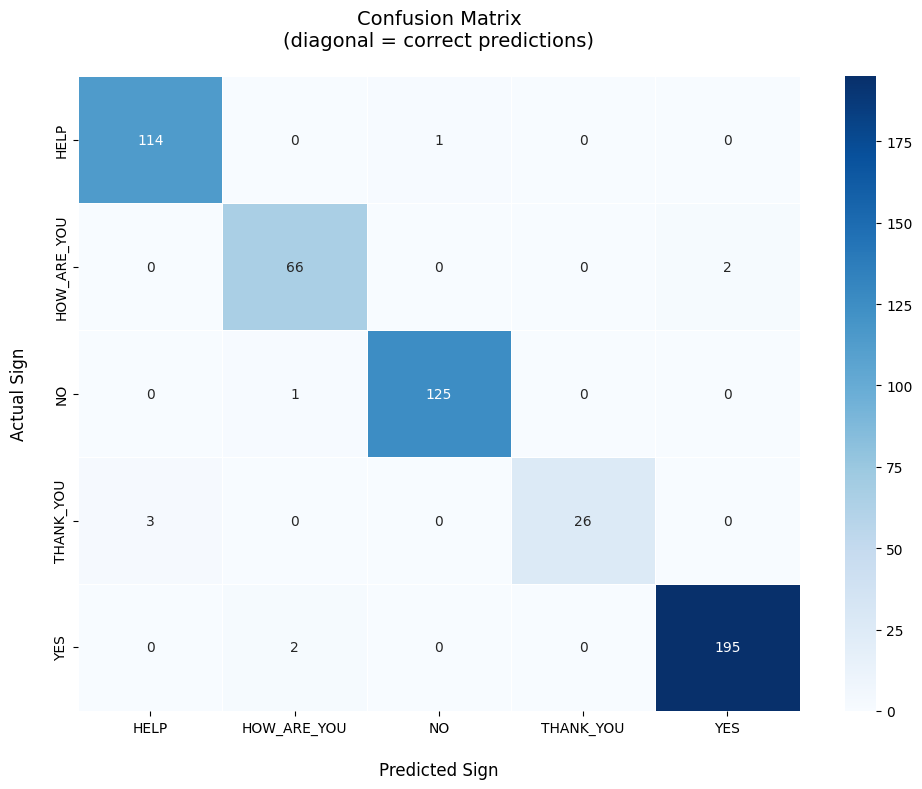


Most confused pairs:
  THANK_YOU → mistaken as HELP: 3 times (10%)


In [ ]:
if 'y_pred' in dir():
    cm = confusion_matrix(y_test, y_pred, labels=sorted(set(y)))
    sign_names = sorted(set(y))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=sign_names,
        yticklabels=sign_names,
        linewidths=0.5
    )
    plt.xlabel('\nPredicted Sign', fontsize=12)
    plt.ylabel('Actual Sign\n', fontsize=12)
    plt.title('Confusion Matrix\n(diagonal = correct predictions)\n', fontsize=14)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Sign Language Dataset/ASL/confusion_matrix.png', dpi=150)
    plt.show()

    # Show which pairs get confused most
    print('\nMost confused pairs:')
    for i in range(len(sign_names)):
        for j in range(len(sign_names)):
            if i != j and cm[i][j] > 0:
                pct = cm[i][j] / cm[i].sum() * 100
                if pct > 5:
                    print(f'  {sign_names[i]} → mistaken as {sign_names[j]}: {cm[i][j]} times ({pct:.0f}%)')
else:
    print('⚠️ Train the model first (run Cell 10)')

In [13]:
if len(data) > 0 and 'trained_model' in dir():
    save_path = '/content/drive/MyDrive/Sign Language Dataset/ASL'

    model_save = {
        'model': trained_model,
        'scaler': trained_scaler,
        'signs': list(set(labels)),
        'sign_translations': {
            'HOW_ARE_YOU': {'english': 'How Are You', 'filipino': 'Kamusta ka'},
            'THANK_YOU': {'english': 'Thank you!', 'filipino': 'Salamat!'},
            'HELP': {'english': 'I need help', 'filipino': 'Kailangan ko ng tulong'},
            'YES': {'english': 'Yes', 'filipino': 'Oo'},
            'NO': {'english': 'No', 'filipino': 'Hindi'}
        },
        'accuracy': accuracy,
        'cv_accuracy': cv_scores.mean(),
        'n_samples': len(data),
        'n_features': X.shape[1],
        'feature_engineering': True
    }

    with open(f'{save_path}/asl_model_improved.pkl', 'wb') as f:
        pickle.dump(model_save, f)

    training_data = {
        'data': data,
        'raw_data': raw_data,
        'labels': labels,
        'signs': list(set(labels)),
        'n_samples': len(data)
    }

    with open(f'{save_path}/training_data_improved.pkl', 'wb') as f:
        pickle.dump(training_data, f)

    print('✓ Files saved:')
    print(f'  Model: {save_path}/asl_model_improved.pkl')
    print(f'  Data:  {save_path}/training_data_improved.pkl')
    print(f'  Accuracy: {accuracy * 100:.1f}% (CV: {cv_scores.mean() * 100:.1f}%)')
    print(f'  Signs: {list(set(labels))}')
else:
    print('⚠️ No model to save - train first')

✓ Files saved:
  Model: /content/drive/MyDrive/Sign Language Dataset/ASL/asl_model_improved.pkl
  Data:  /content/drive/MyDrive/Sign Language Dataset/ASL/training_data_improved.pkl
  Accuracy: 98.3% (CV: 98.2%)
  Signs: ['THANK_YOU', 'YES', 'HELP', 'HOW_ARE_YOU', 'NO']


In [ ]:
if 'trained_model' in dir() and len(raw_data) > 0:
    print('Quick test - predicting on random samples:\n')

    test_indices = []
    for sign in set(labels):
        sign_indices = [i for i, l in enumerate(labels) if l == sign]
        chosen = np.random.choice(sign_indices, min(3, len(sign_indices)), replace=False)
        test_indices.extend(chosen)

    correct = 0
    total = 0

    for idx in test_indices:
        raw = raw_data[idx]
        true_label = labels[idx]

        normalized = normalize_landmarks(raw)
        if normalized is not None:
            features = engineer_features(normalized)
            X_test_single = trained_scaler.transform([features])
            pred = trained_model.predict(X_test_single)[0]
            prob = max(trained_model.predict_proba(X_test_single)[0])

            status = '✓' if pred == true_label else '✗'
            if pred == true_label:
                correct += 1
            total += 1

            print(f'  {status} True: {true_label:15s} → Predicted: {pred:15s} ({prob:.0%})')

    print(f'\nQuick test: {correct}/{total} correct ({correct/total*100:.0f}%)')
else:
    print('⚠️ Train the model first')

Quick test - predicting on random samples:

  ✓ True: THANK_YOU       → Predicted: THANK_YOU       (98%)
  ✓ True: THANK_YOU       → Predicted: THANK_YOU       (100%)
  ✓ True: THANK_YOU       → Predicted: THANK_YOU       (99%)
  ✓ True: YES             → Predicted: YES             (100%)
  ✓ True: YES             → Predicted: YES             (100%)
  ✓ True: YES             → Predicted: YES             (100%)
  ✓ True: HELP            → Predicted: HELP            (98%)
  ✓ True: HELP            → Predicted: HELP            (100%)
  ✓ True: HELP            → Predicted: HELP            (99%)
  ✓ True: HOW_ARE_YOU     → Predicted: HOW_ARE_YOU     (94%)
  ✓ True: HOW_ARE_YOU     → Predicted: HOW_ARE_YOU     (99%)
  ✓ True: HOW_ARE_YOU     → Predicted: HOW_ARE_YOU     (100%)
  ✓ True: NO              → Predicted: NO              (100%)
  ✓ True: NO              → Predicted: NO              (100%)
  ✓ True: NO              → Predicted: NO              (99%)

Quick test: 15/15 correct (100%)